# 05 - Physikalisch motivierte Merkmale aus dem Rohsignal

Statt einzelner Messpunkte werden jetzt die **Dynamik innerhalb der
Temperaturphasen** und eine **Adaptive Lineare Approximation (ALA)**
verwendet.

Verglichen werden vier Ridge-Modelle:

1. 48 rohe Temperaturgrenzpunkte als Referenz,
2. Phasenmerkmale einschließlich Zeitkonstante,
3. ALA-Mittelwerte und -Steigungen,
4. Phasenmerkmale und ALA gemeinsam.

Sensor A, Kanal 0 und die bisherigen UGM-Splits bleiben unverändert.

## Software, physikalische Annahmen und Parameter

**Eingaben**

- GAS wählt das zu quantifizierende Gas.
- N_ALA_SEGMENTS bestimmt die Zahl adaptiver linearer Abschnitte. Mehr Segmente
  rekonstruieren feiner, erzeugen aber zweimal so viele ALA-Merkmale.
- RIDGE_ALPHAS ist eine Folge positiver Regularisierungsstärken. None erzeugt
  logarithmisch verteilte Werte von 10 hoch -4 bis 10 hoch 6.

physics_features.py teilt den Zyklus in 24 bekannte Temperaturphasen. Pro Phase
werden Start, Ende, Hub, Anfangssteigung, tau63, Exponentialfehler und ein
Qualitätsflag berechnet. tau63 ist die Zeit bis 63,2 Prozent des beobachteten
Hubs und entspricht nur bei einer Antwort erster Ordnung der physikalischen
Zeitkonstante.

Die ALA-Stützstellen werden aus dem Trainingsmedian gelernt. Für jedes Segment
werden Mittelwert und Steigung erzeugt. NumPy übernimmt Vektorisierung und
Ausgleichsgeraden; Matplotlib visualisiert Phasenfit und ALA-Rekonstruktion.
sklearn.linear_model.Ridge löst die lineare Regression mit L2-Regularisierung.
alpha = 0 nähert sich unregularisierten kleinsten Quadraten; großes alpha
schrumpft Koeffizienten stärker.

Für einen vollständigen exponentiellen Fit könnte scipy.optimize.curve_fit mit
R_inf, Amplitude und tau als Parametern eingesetzt werden. Bei kurzen,
nichtmonotonen Phasen ist tau63 robuster und leichter zu erklären. Skalierung,
ALA-Grenzen und alpha-Auswahl sehen keine Testdaten.

In [1]:
GAS = "hydrogen"
N_ALA_SEGMENTS = 50
RIDGE_ALPHAS = None

In [2]:
from pathlib import Path
from html import escape
import sys
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML, display
from sklearn.linear_model import Ridge

HERE = Path.cwd()
if not (HERE / "dataset_pipeline.py").exists():
    HERE = HERE / "Evaluation Seminar" / "Neuaufbau"
sys.path.insert(0, str(HERE.resolve()))

from dataset_pipeline import *
from physics_features import (
    extract_ala_features,
    extract_phase_features,
    learn_ala_breakpoints,
    reconstruct_ala,
    temperature_phases,
)

if GAS not in GAS_TARGETS:
    raise ValueError(f"Unbekanntes Gas: {GAS}")
if RIDGE_ALPHAS is None:
    RIDGE_ALPHAS = np.logspace(-4, 6, 21)
plt.style.use("seaborn-v0_8-whitegrid")
splits = prepare_splits("stored")

def show_table(rows, columns, digits=3):
    def formatted(value):
        if isinstance(value, (float, np.floating)):
            return f"{value:.{digits}f}"
        return str(value)
    header = "".join(f"<th>{escape(column)}</th>" for column in columns)
    body = "".join(
        "<tr>" + "".join(
            f"<td>{escape(formatted(row[column]))}</td>" for column in columns
        ) + "</tr>"
        for row in rows
    )
    display(HTML(f"<table><thead><tr>{header}</tr></thead><tbody>{body}</tbody></table>"))

## 1. Zeitkonstante und weitere Phasenmerkmale

Jede der zwölf 400-°C-Phasen und jede der zwölf Niedrigtemperaturphasen
wird separat betrachtet. Pro Phase entstehen:

- Start- und Endniveau,
- Signalhub,
- Anfangssteigung,
- Zeit bis 63,2 % des beobachteten Hubs,
- Fehler einer Antwort erster Ordnung,
- Qualitätsflag, ob die 63,2-%-Schwelle erreicht wurde.

Für ein ideales System erster Ordnung

R(t) = R_start + ΔR · (1 - exp(-t/τ))

ist die Zeit bis 63,2 % genau die Zeitkonstante τ. Hier ist sie bewusst
ein robuster, direkter Schätzer und kein erzwungener nichtlinearer Fit.

In [3]:
phase_features = {}
for split in SPLIT_NAMES:
    values, phase_names = extract_phase_features(splits[split]["X"])
    phase_features[split] = values

print("Temperaturphasen:", len(temperature_phases()))
print("Phasenmerkmale:", len(phase_names))
print("Form Train:", phase_features["train"].shape)

tau_columns = [i for i, name in enumerate(phase_names) if name.endswith("tau63_s")]
found_columns = [
    i for i, name in enumerate(phase_names)
    if name.endswith("tau_crossing_found")
]
tau_summary = []
for tau_col, found_col in zip(tau_columns, found_columns):
    tau_summary.append({
        "Phase": phase_names[tau_col].replace("__tau63_s", ""),
        "Median tau [s]": np.median(phase_features["train"][:, tau_col]),
        "Schwelle erreicht [%]":
            100 * np.mean(phase_features["train"][:, found_col]),
    })
show_table(
    tau_summary,
    ["Phase", "Median tau [s]", "Schwelle erreicht [%]"],
    digits=2,
)

Temperaturphasen: 24
Phasenmerkmale: 168
Form Train: (1090, 168)


Phase,Median tau [s],Schwelle erreicht [%]
step00_high_t400,1.87,100.00
step00_low_t100,0.08,100.00
step01_high_t400,2.77,100.00
step01_low_t125,0.08,100.00
step02_high_t400,2.69,100.00
step02_low_t150,0.07,100.00
step03_high_t400,2.67,100.00
step03_low_t175,5.30,99.91
step04_high_t400,2.60,100.00
step04_low_t200,4.12,100.00


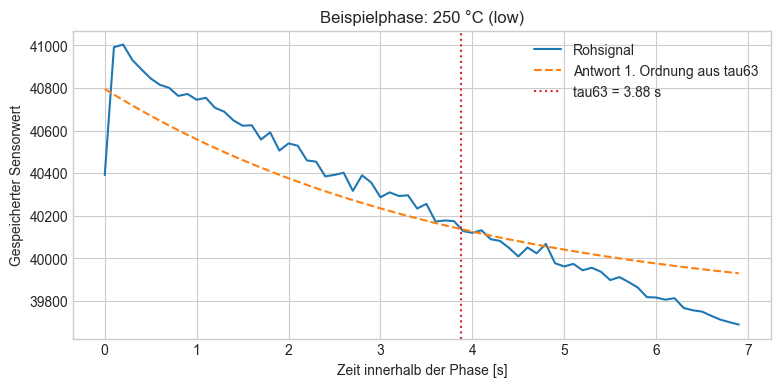

In [4]:
example_index = len(splits["train"]["X"]) // 2
cycle = splits["train"]["X"][example_index, 0].astype(float)
phase = temperature_phases()[13]  # 250 °C low
values = cycle[phase.start:phase.stop]
local_features, local_names = extract_phase_features(
    splits["train"]["X"][example_index:example_index + 1]
)
prefix = phase.label + "__"
lookup = {
    name.removeprefix(prefix): local_features[0, i]
    for i, name in enumerate(local_names) if name.startswith(prefix)
}
t = np.arange(len(values)) / SAMPLE_RATE_HZ
fitted = lookup["start"] + lookup["amplitude"] * (
    1 - np.exp(-t / max(lookup["tau63_s"], 1 / SAMPLE_RATE_HZ))
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t, values, label="Rohsignal")
ax.plot(t, fitted, "--", label="Antwort 1. Ordnung aus tau63")
ax.axvline(lookup["tau63_s"], color="tab:red", linestyle=":",
           label=f"tau63 = {lookup['tau63_s']:.2f} s")
ax.set(xlabel="Zeit innerhalb der Phase [s]", ylabel="Gespeicherter Sensorwert",
       title=f"Beispielphase: {phase.temperature_c} °C ({phase.kind})")
ax.legend()
plt.show()

## 2. Adaptive Lineare Approximation

Die ALA zerlegt den Zyklus an den Stellen mit großem
Rekonstruktionsfehler. Die Stützstellen werden **nur aus dem Median des
Trainingssignals** gelernt und danach für alle Splits festgehalten.
Dadurch haben Mittelwert und Steigung jedes Segments in jeder Zeile
dieselbe Bedeutung.

Mit 50 Segmenten entstehen bei einem einzigen Sensorkanal 100 Merkmale.
Das folgt der in der Literatur häufig verwendeten Kombination aus
Segmentmittelwert und Segmentsteigung.

In [5]:
train_reference = np.median(splits["train"]["X"][:, 0, :], axis=0)
ala_breakpoints = learn_ala_breakpoints(
    train_reference, n_segments=N_ALA_SEGMENTS
)
ala_reconstruction = reconstruct_ala(train_reference, ala_breakpoints)

ala_features = {}
for split in SPLIT_NAMES:
    values, ala_names = extract_ala_features(
        splits[split]["X"], ala_breakpoints
    )
    ala_features[split] = values

reconstruction_rmse = np.sqrt(
    np.mean((train_reference - ala_reconstruction) ** 2)
)
print("ALA-Stützstellen:", len(ala_breakpoints))
print("ALA-Merkmale:", len(ala_names))
print(f"RMSE der Median-Rekonstruktion: {reconstruction_rmse:.2f}")

ALA-Stützstellen: 51
ALA-Merkmale: 100
RMSE der Median-Rekonstruktion: 1359.52


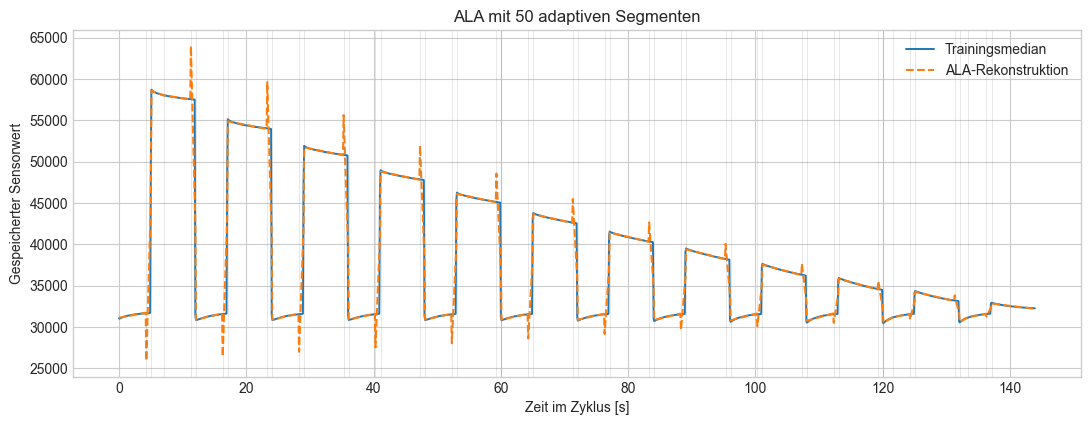

In [6]:
time_s = np.arange(CYCLE_SAMPLES) / SAMPLE_RATE_HZ
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(time_s, train_reference, label="Trainingsmedian", linewidth=1.4)
ax.plot(time_s, ala_reconstruction, "--", label="ALA-Rekonstruktion")
for point in ala_breakpoints[1:-1]:
    ax.axvline(point / SAMPLE_RATE_HZ, color="grey", alpha=0.18, linewidth=0.7)
ax.set(xlabel="Zeit im Zyklus [s]", ylabel="Gespeicherter Sensorwert",
       title=f"ALA mit {N_ALA_SEGMENTS} adaptiven Segmenten")
ax.legend()
plt.show()

## 3. Fairer Modellvergleich

Die Ridge-Regularisierung ist hier sinnvoll, weil viele Mittelwerte,
Steigungen und Phasenwerte miteinander korrelieren. Mittelwert,
Standardabweichung und Ridge-Stärke werden nur aus Train beziehungsweise
über Validation bestimmt. Test und test_extra beeinflussen das Modell
nicht.

In [7]:
boundary_indices = [point.index for point in temperature_boundary_points()]
raw_boundary_features = {
    split: splits[split]["X"][:, 0, boundary_indices].astype(float)
    for split in SPLIT_NAMES
}
combined_features = {
    split: np.column_stack((phase_features[split], ala_features[split]))
    for split in SPLIT_NAMES
}
feature_sets = {
    "48 rohe Grenzpunkte": raw_boundary_features,
    "Phasendynamik": phase_features,
    "ALA": ala_features,
    "Phasendynamik + ALA": combined_features,
}

def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    residual = y_true - np.asarray(y_pred, dtype=float)
    mse = float(np.mean(residual ** 2))
    denominator = float(np.sum((y_true - y_true.mean()) ** 2))
    return {
        "R2": 1 - float(np.sum(residual ** 2)) / denominator,
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "MAE": float(np.mean(np.abs(residual))),
    }

def tune_ridge(feature_dict):
    mean = feature_dict["train"].mean(axis=0)
    scale = feature_dict["train"].std(axis=0)
    scale[scale < 1e-12] = 1.0

    def standardized(split):
        return (feature_dict[split] - mean) / scale

    y_train = splits["train"]["targets"][GAS].astype(float)
    y_val = splits["val"]["targets"][GAS].astype(float)
    trials = []
    for alpha in RIDGE_ALPHAS:
        model = Ridge(alpha=float(alpha)).fit(standardized("train"), y_train)
        prediction = model.predict(standardized("val"))
        rmse = regression_metrics(y_val, prediction)["RMSE"]
        trials.append((rmse, float(alpha), model))
    _, best_alpha, model = min(trials, key=lambda item: item[0])
    predictions = {
        split: model.predict(standardized(split)) for split in SPLIT_NAMES
    }
    return model, best_alpha, predictions

fitted = {}
rows = []
for feature_name, feature_dict in feature_sets.items():
    model, alpha, predictions = tune_ridge(feature_dict)
    fitted[feature_name] = (model, alpha, predictions)
    for split in SPLIT_NAMES:
        result = regression_metrics(
            splits[split]["targets"][GAS], predictions[split]
        )
        rows.append({
            "Merkmale": feature_name,
            "Anzahl": feature_dict["train"].shape[1],
            "Alpha": alpha,
            "Split": split,
            **result,
        })

show_table(
    rows, ["Merkmale", "Anzahl", "Alpha", "Split", "R2", "MSE", "RMSE", "MAE"]
)

Merkmale,Anzahl,Alpha,Split,R2,MSE,RMSE,MAE
48 rohe Grenzpunkte,48,1.000,train,0.868,27746.389,166.572,130.840
48 rohe Grenzpunkte,48,1.000,val,0.885,23867.993,154.493,123.803
48 rohe Grenzpunkte,48,1.000,test,0.846,33114.868,181.975,141.138
48 rohe Grenzpunkte,48,1.000,test_extra,0.214,167267.078,408.983,334.746
Phasendynamik,168,0.100,train,0.919,16953.639,130.206,101.751
Phasendynamik,168,0.100,val,0.924,15823.254,125.791,99.222
Phasendynamik,168,0.100,test,0.905,20457.783,143.031,112.533
Phasendynamik,168,0.100,test_extra,0.245,160627.811,400.784,323.979
ALA,100,0.316,train,0.924,16030.591,126.612,99.561
ALA,100,0.316,val,0.925,15567.044,124.768,98.108


In [8]:
compact = []
for name in feature_sets:
    values = {row["Split"]: row for row in rows if row["Merkmale"] == name}
    compact.append({
        "Merkmale": name,
        **{f"R2 {split}": values[split]["R2"] for split in SPLIT_NAMES},
        **{f"RMSE {split}": values[split]["RMSE"] for split in SPLIT_NAMES},
    })
show_table(compact, list(compact[0]), digits=3)

Merkmale,R2 train,R2 val,R2 test,R2 test_extra,RMSE train,RMSE val,RMSE test,RMSE test_extra
48 rohe Grenzpunkte,0.868,0.885,0.846,0.214,166.572,154.493,181.975,408.983
Phasendynamik,0.919,0.924,0.905,0.245,130.206,125.791,143.031,400.784
ALA,0.924,0.925,0.905,0.349,126.612,124.768,142.660,372.068
Phasendynamik + ALA,0.919,0.923,0.905,0.350,130.124,126.213,142.972,371.949


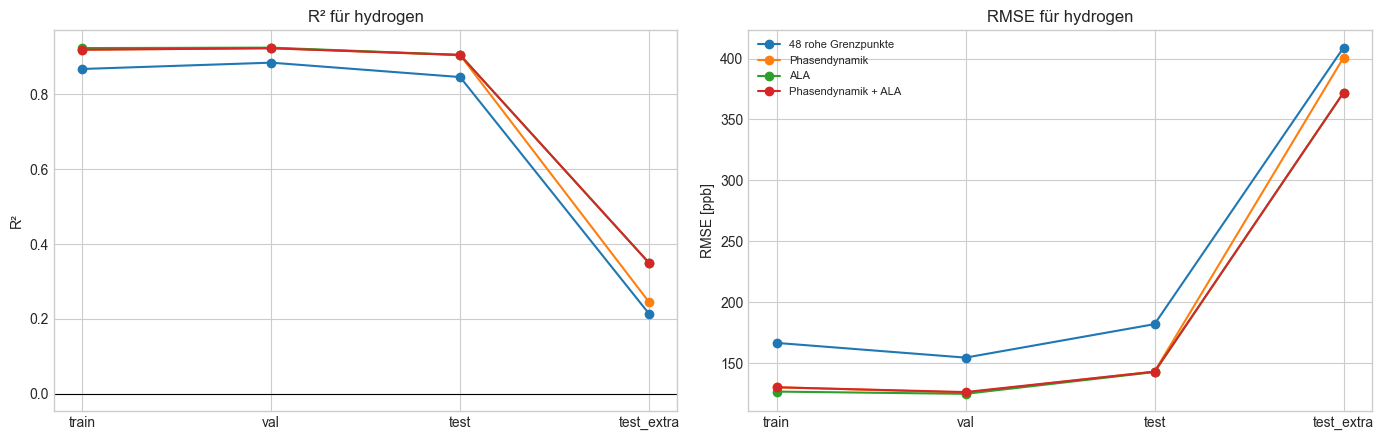

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for feature_name in feature_sets:
    subset = [row for row in rows if row["Merkmale"] == feature_name]
    axes[0].plot([row["Split"] for row in subset],
                 [row["R2"] for row in subset], marker="o", label=feature_name)
    axes[1].plot([row["Split"] for row in subset],
                 [row["RMSE"] for row in subset], marker="o", label=feature_name)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set(title=f"R² für {GAS}", ylabel="R²")
axes[1].set(title=f"RMSE für {GAS}", ylabel="RMSE [ppb]")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 4. Welche physikalischen Merkmale tragen Information?

In [10]:
y_train = splits["train"]["targets"][GAS].astype(float)
correlations = []
for index, name in enumerate(phase_names):
    x = phase_features["train"][:, index]
    if np.std(x) < 1e-12:
        continue
    correlation = np.corrcoef(x, y_train)[0, 1]
    if not np.isfinite(correlation):
        continue
    correlations.append({
        "Merkmal": name,
        "Korrelation Train": correlation,
        "|Korrelation|": abs(correlation),
    })
correlation_table = sorted(
    correlations, key=lambda row: row["|Korrelation|"], reverse=True
)[:20]
show_table(
    correlation_table,
    ["Merkmal", "Korrelation Train", "|Korrelation|"],
)

Merkmal,Korrelation Train,|Korrelation|
step10_low_t350__amplitude,-0.801,0.801
step11_low_t375__amplitude,-0.790,0.790
step11_high_t400__amplitude,0.787,0.787
step11_high_t400__initial_slope_per_s,0.786,0.786
step10_high_t400__initial_slope_per_s,0.759,0.759
step09_low_t325__amplitude,-0.755,0.755
step10_high_t400__amplitude,0.750,0.750
step00_high_t400__amplitude,0.750,0.750
step00_high_t400__initial_slope_per_s,0.732,0.732
step10_high_t400__tau63_s,-0.709,0.709


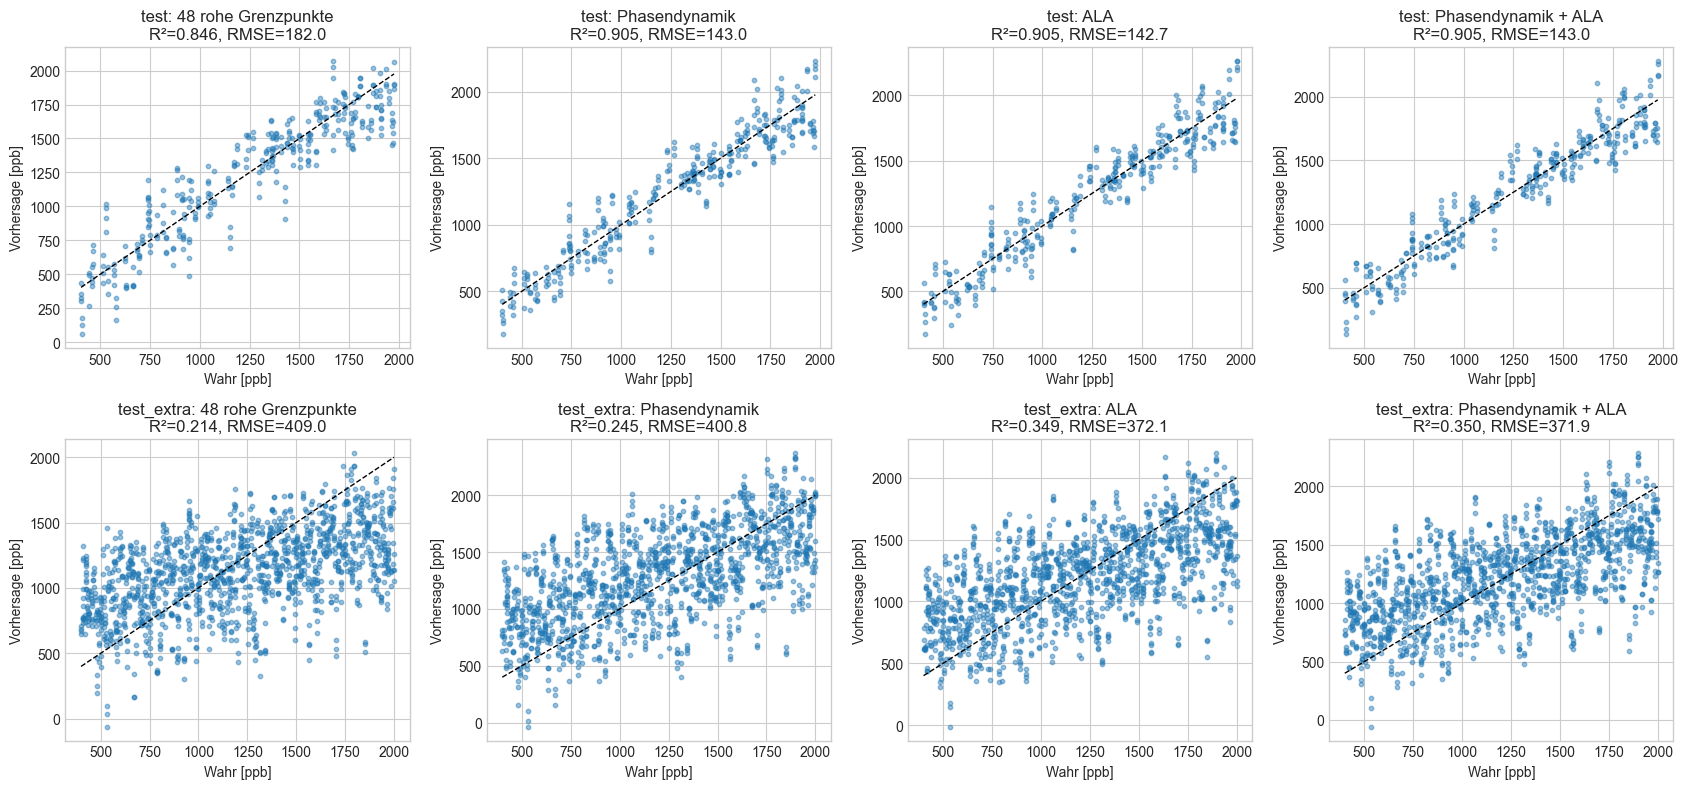

In [11]:
models_to_show = ["48 rohe Grenzpunkte", "Phasendynamik", "ALA",
                  "Phasendynamik + ALA"]
evaluation_splits = ("test", "test_extra")
fig, axes = plt.subplots(2, 4, figsize=(17, 8))
for row, split in enumerate(evaluation_splits):
    y_true = splits[split]["targets"][GAS].astype(float)
    lower = float(y_true.min())
    upper = float(y_true.max())
    for column, name in enumerate(models_to_show):
        ax = axes[row, column]
        prediction = fitted[name][2][split]
        ax.scatter(y_true, prediction, s=10, alpha=0.45)
        ax.plot([lower, upper], [lower, upper], "k--", linewidth=1)
        score = regression_metrics(y_true, prediction)
        ax.set(
            xlabel="Wahr [ppb]", ylabel="Vorhersage [ppb]",
            title=(
                f"{split}: {name}\n"
                f"R²={score['R2']:.3f}, RMSE={score['RMSE']:.1f}"
            ),
        )
plt.tight_layout()
plt.show()

## Einordnung

- **tau63** ist physikalisch interpretierbar, aber nur dann eine echte
  Material-Zeitkonstante, wenn die Phase näherungsweise einer Antwort
  erster Ordnung folgt. Der Fitfehler und das Schwellen-Flag machen
  Abweichungen sichtbar.
- Die **ALA** ist datenadaptiv, aber nicht gasspezifisch: Ihre
  Segmentgrenzen werden aus der Signalform im Training gelernt.
- Eine hohe Validation-Leistung garantiert keine Extrapolation in
  **test_extra**. Dieser Split bleibt absichtlich der Härtetest.
- ALA wird hier wie in der MOS-Literatur als Merkmalsextraktion
  verstanden, nicht als separates Regressionsmodell.

Literaturbeispiele:
[Baur et al., JSSS 2023](https://jsss.copernicus.org/articles/12/45/2023/)
und
[Robin et al., Atmosphere 2023](https://www.mdpi.com/2073-4433/14/7/1123).